In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression as lr 
import matplotlib.pyplot as plt

## Data:

In [2]:
path = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\data\raw\synthetic_dataset_A_non-iid.csv"
df = pd.read_csv(path)

# Vi standardisere vores features.
variables = df.columns[1:27].tolist()
scaler = StandardScaler()
df[variables] = scaler.fit_transform(df[variables])

# Test Data:
path_testdata = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\data\processed\A\global_test_set_non-iid.csv"
test_data = pd.read_csv(path_testdata)
test_data[variables] = scaler.transform(test_data[variables])

## Functions:

In [7]:
def fit_centralized_models(train_df, variables, complications):
    """
    Fitter én lineær regression pr. complication.
    """
    models = {}

    n = len(train_df)
    d = len(variables)

    X_train = np.zeros((n, d))
    for i in range(d):
        X_train[:, i] = train_df[variables[i]]

    for complication in complications:
        y_train = train_df[complication].to_numpy()

        model = lr()
        model.fit(X_train, y_train)

        models[complication] = {
            "intercept": model.intercept_,
            "coef": model.coef_
        }

    return models


def predict_and_group_centralized(test_df, variables, models):
    """
    Laver predictions og kvatil-grupper for hver complication på test_df.
    
    Tilføjer for hver complication:
      - Risk_XXX_group
    
    Returnerer:
      out_df, cutoffs
    """
    out = test_df.copy()
    cutoffs = {}

    n = len(test_df)
    d = len(variables)

    X_test = np.zeros((n, d))
    for i in range(d):
        X_test[:, i] = test_df[variables[i]]

    for complication, params in models.items():
        intercept = params["intercept"]
        coefs = params["coef"]

        y_hat = intercept + X_test @ coefs

        q1 = np.quantile(y_hat, 1/3)
        q2 = np.quantile(y_hat, 2/3)

        groups = np.where(
            y_hat <= q1, 0,
            np.where(y_hat <= q2, 1, 2)
        )

        out[f"{complication}_group"] = groups

        cutoffs[complication] = {
            "q1": q1,
            "q2": q2
        }

    return out, cutoffs


def run_centralized_baseline(train_df, test_df, variables, complications):
    """
    Samlet pipeline:
      1. fit modeller på train
      2. predict + group på test
      3. beregn F1 med dine eksisterende metric-funktioner
    
    Returnerer en dictionary med alt relevant output.
    """
    models = fit_centralized_models(train_df, variables, complications)
    test_with_preds, cutoffs = predict_and_group_centralized(test_df, variables, models)
    results, overall_macro_f1 = metrics_for_all_complications(test_with_preds, complications)

    return {
        "models": models,
        "test_with_preds": test_with_preds,
        "cutoffs": cutoffs,
        "results": results,
        "overall_macro_f1": overall_macro_f1
    }

def metrics_for_one_complication(df, complication):
    """
    complication fx 'Risk_AlveolarOsteitis'
    
    Bruger:
      true: Risk_Category_AlveolarOsteitis
      pred: Risk_AlveolarOsteitis_group
    """
    
    true_col = complication.replace("Risk_", "Risk_Category_", 1)
    pred_col = f"{complication}_group"
    
    y_true = df[true_col].to_numpy()
    y_pred = df[pred_col].to_numpy()
    
    results = {}
    
    for cls in [0, 1, 2]:
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        results[cls] = {
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1
        }
    
    macro_f1 = np.mean([results[cls]["f1"] for cls in [0, 1, 2]])
    
    return {
        "true_col": true_col,
        "pred_col": pred_col,
        "per_class": results,
        "macro_f1": macro_f1
    }

def metrics_for_all_complications(df, complications):
    all_results = {}
    macro_f1s = []

    for complication in complications:
        res = metrics_for_one_complication(df, complication)
        all_results[complication] = res
        macro_f1s.append(res["macro_f1"])

    # svarer til f1_global_macro i din pipeline
    overall_macro_f1 = np.mean(macro_f1s)

    return all_results, overall_macro_f1

# function that plots the absolute values of the coefficients
def plot_magnitude(coefs, variable_names, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    magnitudes = np.abs(coefs)
    
    ax.bar(range(len(coefs)), magnitudes)
    
    ax.set_xticks(range(len(coefs)))
    ax.set_xticklabels(variable_names, rotation=90)
    
    ax.set_title(title)
    ax.set_xlabel("Variables")
    ax.set_ylabel("|Coefficient|")
    
    plt.tight_layout()
    plt.show()

def plot_all_complications(results, variables):
    for complication, result_dict in results.items():
        plot_magnitude(
            result_dict["coef"],
            variables,
            title=f"Coefficient magnitudes - {complication}"
        )

## Results:

In [5]:

complications = [
    "Risk_AlveolarOsteitis",
    "Risk_SecondaryInfection",
    "Risk_NerveDysesthesia",
    "Risk_Bleeding"
]

centralized_output = run_centralized_baseline(
    train_df=df,
    test_df=test_data,
    variables=variables,
    complications=complications
)

results = centralized_output["results"]
overall_f1 = centralized_output["overall_macro_f1"]
test_with_preds_centralized = centralized_output["test_with_preds"]

for complication, res in results.items():
    print(f"\n--- {complication} ---")
    print(f"True column: {res['true_col']}")
    print(f"Pred column: {res['pred_col']}")

    for cls in [0, 1, 2]:
        vals = res["per_class"][cls]
        print(
            f"Class {cls}: "
            f"Precision={vals['precision']:.3f}, "
            f"Recall={vals['recall']:.3f}, "
            f"F1={vals['f1']:.3f}"
        )

    print(f"Macro F1 = {res['macro_f1']:.3f}")

print("\n==============================")
print(f"CENTRALIZED FINAL F1 = {overall_f1:.3f}")
print("==============================")


--- Risk_AlveolarOsteitis ---
True column: Risk_Category_AlveolarOsteitis
Pred column: Risk_AlveolarOsteitis_group
Class 0: Precision=0.762, Recall=0.790, F1=0.776
Class 1: Precision=0.542, Recall=0.528, F1=0.535
Class 2: Precision=0.716, Recall=0.710, F1=0.713
Macro F1 = 0.675

--- Risk_SecondaryInfection ---
True column: Risk_Category_SecondaryInfection
Pred column: Risk_SecondaryInfection_group
Class 0: Precision=0.697, Recall=0.727, F1=0.712
Class 1: Precision=0.545, Recall=0.525, F1=0.535
Class 2: Precision=0.742, Recall=0.741, F1=0.741
Macro F1 = 0.662

--- Risk_NerveDysesthesia ---
True column: Risk_Category_NerveDysesthesia
Pred column: Risk_NerveDysesthesia_group
Class 0: Precision=0.748, Recall=0.817, F1=0.781
Class 1: Precision=0.619, Recall=0.564, F1=0.590
Class 2: Precision=0.754, Recall=0.765, F1=0.759
Macro F1 = 0.710

--- Risk_Bleeding ---
True column: Risk_Category_Bleeding
Pred column: Risk_Bleeding_group
Class 0: Precision=0.543, Recall=0.633, F1=0.584
Class 1: Prec

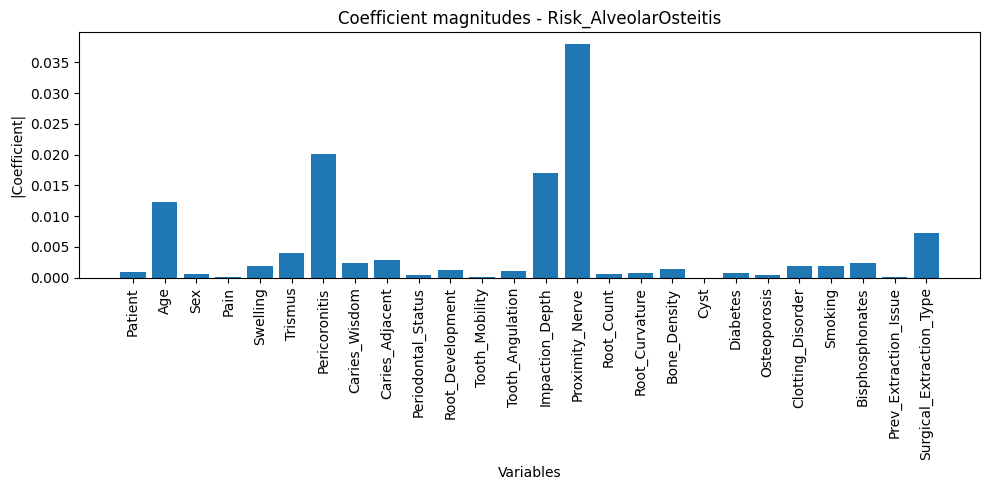

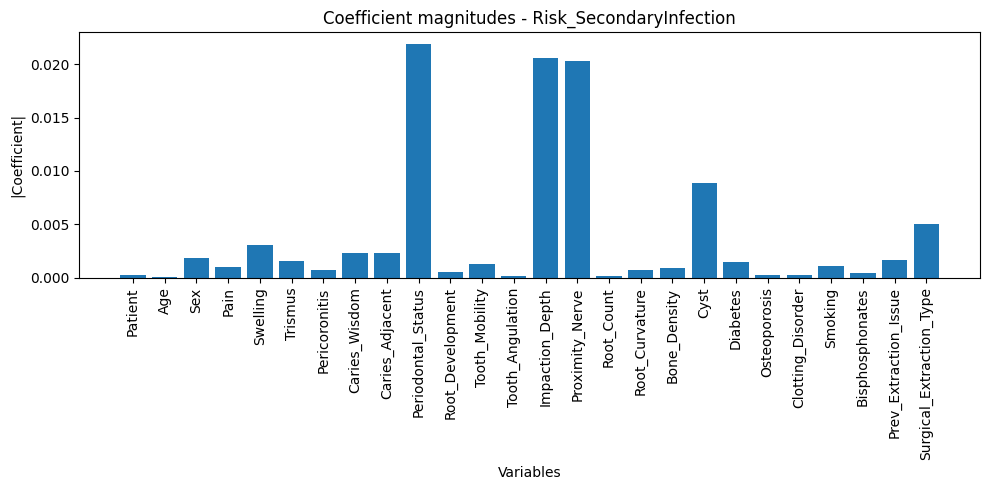

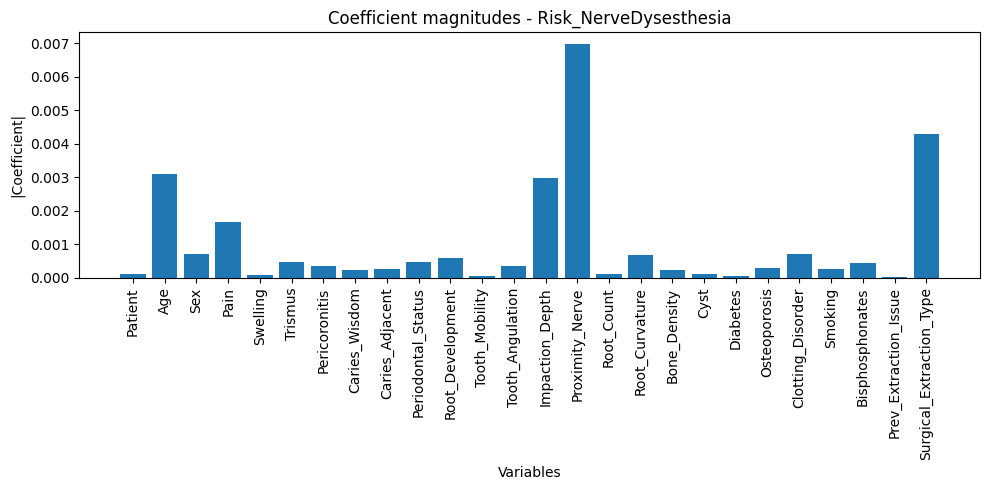

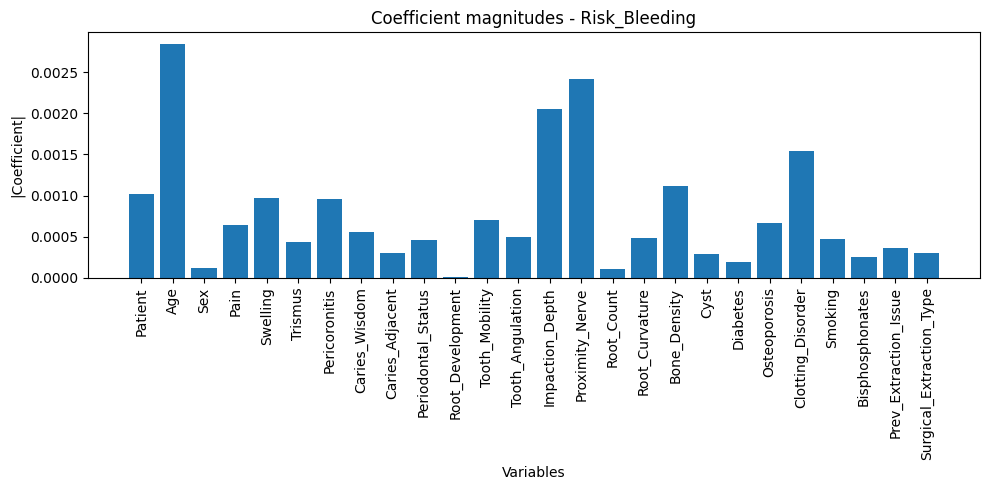

In [8]:
results_centralized = centralized_output["models"]
plot_all_complications(results_centralized, variables)